# Close-attack visualization

Read-only analysis of `Results/close_attack_table.csv`. Run all cells to refresh
the charts after updating that table. This notebook makes **no model calls**.

The current table summarizes **query injection**: pairwise candidates have grades
**3/2**, and setwise/listwise candidates have grades **3/2/2/2**. The attack target
is selected relative to the clean ranking; it is not necessarily grade 2.
`key_injection` is a separate attack and is not represented in this table.

**Success % = successes / valid instances × 100.** Pairwise success is a preference
flip, setwise success is selection of the target, and listwise success is target
promotion to first place. Compare prompts within a paradigm; these are different
success definitions. The summary does not contain requested-instance counts, so
discard rates cannot be reconstructed here. Repeated queries mean these rows are
not independent-trial uncertainty estimates; no confidence intervals are drawn.

The current job uses `defense_qi`. Legacy `defense` results use a different prompt and are excluded by default. Re-run the evaluations to obtain `defense_qi` results; do not relabel old rows.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = next(
    (
        path
        for path in [Path.cwd(), *Path.cwd().parents]
        if (path / "Results" / "update_close_attack_table.py").exists()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from the repository or Results folder.")
CSV_PATH = ROOT / "Results" / "close_attack_table.csv"
EXPORT_DIR = ROOT / "Results" / "close_attack_figures"

# Set a list to filter; None includes every available value.
MODELS = None  # e.g. ["GPT-OSS-20B", "Qwen3-32B"]
DATASETS = None  # e.g. ["TREC-DL-2019"]
PROMPT_MODES = ["standard", "defense_qi"]
SAVE_FIGURES = True
RATE_AXIS_MAX = None  # None fits the data; use 100 for a full percentage axis.

MODEL_LABELS = {
    "openai.gpt-oss-20b-1:0": "GPT-OSS-20B",
    "openai/gpt-oss-20b": "GPT-OSS-20B",
    "qwen.qwen3-32b-v1:0": "Qwen3-32B",
    "Qwen/Qwen3-32B": "Qwen3-32B",
}
SCHEMES = ["pairwise", "setwise", "listwise"]
PROMPTS = ["standard", "defense", "defense_qi"]
COLORS = {"standard": "#2878A5", "defense": "#D77A32", "defense_qi": "#439B78"}
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)


def finish_figure(fig, stem):
    """Display a figure and optionally export its PNG and vector PDF."""
    fig.tight_layout()
    if SAVE_FIGURES:
        EXPORT_DIR.mkdir(parents=True, exist_ok=True)
        for extension in ("png", "pdf"):
            fig.savefig(
                EXPORT_DIR / f"{stem}.{extension}", dpi=200, bbox_inches="tight"
            )
    plt.show()

## Load and check results

Missing combinations remain missing; they are never converted to zero. Rates are
recomputed from counts to avoid rounding error in the defense comparison.
If the CSV is missing, run `Results/update_close_attack_table.py` on the machine
holding the completed raw results, then copy the summary here.

In [2]:
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Missing {CSV_PATH}. Build or copy the close-attack table first."
    )
raw = pd.read_csv(CSV_PATH)
required = {"Dataset", "Model", "Paradigm", "Prompt", "Success %", "Success", "Valid"}
if not required.issubset(raw.columns):
    raise ValueError(f"Missing columns: {sorted(required - set(raw.columns))}")
if raw.empty:
    raise ValueError("The close-attack table has no completed runs yet.")
keys = ["Dataset", "Model", "Paradigm", "Prompt"]
if raw[keys].isna().any().any() or raw.duplicated(keys).any():
    raise ValueError(
        "Missing identifiers or duplicate runs: rebuild the summary table."
    )
for column in ["Success", "Valid", "Success %"]:
    raw[column] = pd.to_numeric(raw[column], errors="raise")
if raw[["Success", "Valid", "Success %"]].isna().any().any():
    raise ValueError("Result counts and rates must not be missing.")
if ((raw["Success"] < 0) | (raw["Valid"] < raw["Success"])).any():
    raise ValueError("Counts must satisfy 0 <= Success <= Valid.")
raw["Rate"] = 100 * raw["Success"] / raw["Valid"].where(raw["Valid"] > 0)
if ((raw["Rate"] - raw["Success %"]).abs() > 0.011).any():
    raise ValueError("Saved rates disagree with counts: rebuild the summary table.")
df = raw.copy()
df["Model"] = df["Model"].replace(MODEL_LABELS)
df["Dataset"] = df["Dataset"].str.replace(
    "msmarco-passage/trec-dl-", "TREC-DL-", regex=False
)
if MODELS is not None:
    df = df[df["Model"].isin(MODELS)]
if DATASETS is not None:
    df = df[df["Dataset"].isin(DATASETS)]
df = df[df["Prompt"].isin(PROMPT_MODES)]
if df.empty:
    raise ValueError("No runs match the selected filters.")
df = df.sort_values(keys).reset_index(drop=True)
print(
    f"Loaded {len(df)} runs; {df['Model'].nunique()} model(s), "
    f"{df['Dataset'].nunique()} dataset(s)."
)
display(df[keys + ["Success", "Valid", "Rate"]].round({"Rate": 2}))

Loaded 12 runs; 1 model(s), 2 dataset(s).


,Dataset,Model,Paradigm,Prompt,Success,Valid,Rate
0,TREC-DL-2019,GPT-OSS-20B,listwise,defense_qi,267,3885,6.87
1,TREC-DL-2019,GPT-OSS-20B,listwise,standard,290,3996,7.26
2,TREC-DL-2019,GPT-OSS-20B,pairwise,defense_qi,396,4039,9.80
3,TREC-DL-2019,GPT-OSS-20B,pairwise,standard,339,4023,8.43
4,TREC-DL-2019,GPT-OSS-20B,setwise,defense_qi,320,4022,7.96
5,TREC-DL-2019,GPT-OSS-20B,setwise,standard,264,3985,6.62
6,TREC-DL-2020,GPT-OSS-20B,listwise,defense_qi,292,3941,7.41
7,TREC-DL-2020,GPT-OSS-20B,listwise,standard,301,4049,7.43
8,TREC-DL-2020,GPT-OSS-20B,pairwise,defense_qi,407,4090,9.95
9,TREC-DL-2020,GPT-OSS-20B,pairwise,standard,366,4082,8.97


## Standard versus query-injection defense

Each panel is one dataset/model. Bar labels show success percentages among valid
instances. All panels share a scale; an absent bar means no valid result, not 0%.

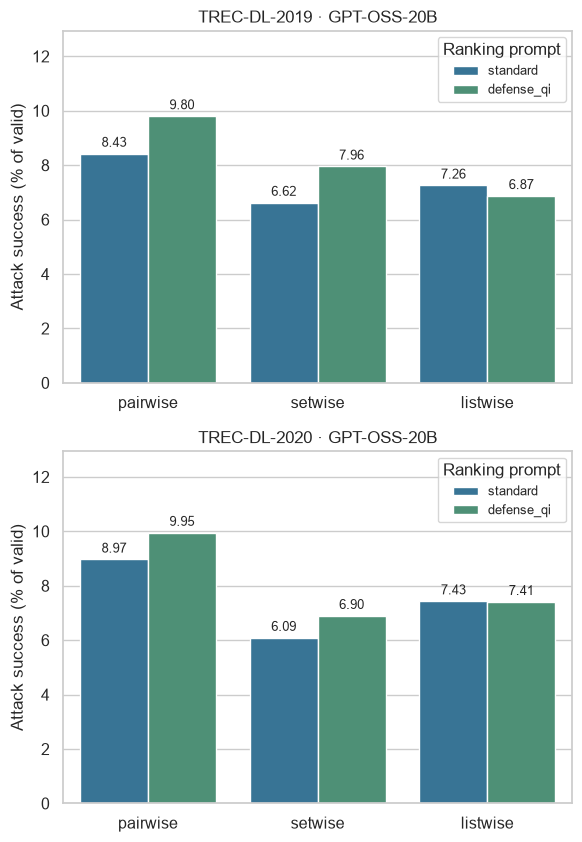

In [3]:
datasets = sorted(df["Dataset"].unique())
models = sorted(df["Model"].unique())
prompt_order = [prompt for prompt in PROMPTS if prompt in set(df["Prompt"])]
unknown = set(df["Prompt"]) - set(PROMPTS)
if unknown:
    raise ValueError(f"Add plot labels for these prompt modes: {sorted(unknown)}")
available_max = df["Rate"].max()
axis_max = RATE_AXIS_MAX or min(
    100, max(10, available_max * 1.3 if pd.notna(available_max) else 10)
)
fig, axes = plt.subplots(
    len(datasets),
    len(models),
    figsize=(6 * len(models), 4.3 * len(datasets)),
    squeeze=False,
)
for row, dataset in enumerate(datasets):
    for col, model in enumerate(models):
        ax = axes[row, col]
        subset = df[(df["Dataset"] == dataset) & (df["Model"] == model)]
        if subset["Rate"].notna().any():
            sns.barplot(
                data=subset,
                x="Paradigm",
                y="Rate",
                hue="Prompt",
                order=SCHEMES,
                hue_order=prompt_order,
                palette=COLORS,
                errorbar=None,
                ax=ax,
            )
            for container in ax.containers:
                ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
            ax.legend(title="Ranking prompt", fontsize=9)
        else:
            ax.text(0.5, 0.5, "No valid results", ha="center", transform=ax.transAxes)
        ax.set(
            title=f"{dataset} · {model}",
            xlabel="",
            ylabel="Attack success (% of valid)",
            ylim=(0, axis_max),
        )
finish_figure(fig, "close_attack_standard_vs_defense")

## Result coverage and heatmap

The count matrix gives the denominator behind each rate. Missing cells are blank.
The heatmap uses a fixed 0–100% color scale so future runs remain comparable.

Condition,pairwise / standard,pairwise / defense_qi,setwise / standard,setwise / defense_qi,listwise / standard,listwise / defense_qi
Panel,,,,,,
TREC-DL-2019 · GPT-OSS-20B,4023,4039,3985,4022,3996,3885
TREC-DL-2020 · GPT-OSS-20B,4082,4090,4072,4075,4049,3941


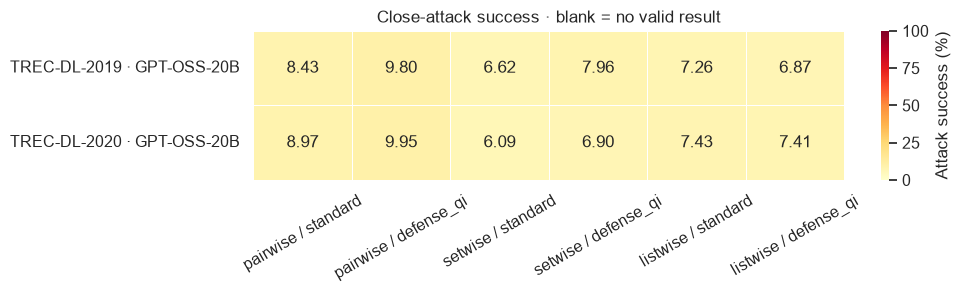

In [4]:
view = df.assign(
    Panel=df["Dataset"] + " · " + df["Model"],
    Condition=df["Paradigm"] + " / " + df["Prompt"],
)
columns = [f"{scheme} / {prompt}" for scheme in SCHEMES for prompt in prompt_order]
rates = view.pivot(index="Panel", columns="Condition", values="Rate").reindex(
    columns=columns
)
counts = view.pivot(index="Panel", columns="Condition", values="Valid").reindex(
    columns=columns
)
display(counts.astype("Int64"))
fig, ax = plt.subplots(
    figsize=(max(10, len(columns) * 1.7), max(2.8, len(rates) * 0.8 + 1.5))
)
sns.heatmap(
    rates,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    linewidths=0.7,
    mask=rates.isna(),
    cbar_kws={"label": "Attack success (%)"},
    ax=ax,
)
ax.set(title="Close-attack success · blank = no valid result", xlabel="", ylabel="")
ax.tick_params(axis="x", rotation=30)
finish_figure(fig, "close_attack_heatmap")

## Query-injection defense effect

**Query-injection defense (`defense_qi`) − standard**, in percentage points. Positive values mean higher attack
success with defense; negative values mean lower attack success. Only completed
pairs with valid denominators appear. This is a descriptive comparison, not a
paired statistical test: clean-stage exclusions can differ between prompt modes.

Prompt                             standard  defense_qi  \
Dataset      Model       Paradigm                         
TREC-DL-2019 GPT-OSS-20B listwise      7.26        6.87   
                         pairwise      8.43        9.80   
                         setwise       6.62        7.96   
TREC-DL-2020 GPT-OSS-20B listwise      7.43        7.41   
                         pairwise      8.97        9.95   
                         setwise       6.09        6.90   

Prompt                             Defense QI − standard (pp)  
Dataset      Model       Paradigm                              
TREC-DL-2019 GPT-OSS-20B listwise                       -0.38  
                         pairwise                        1.38  
                         setwise                         1.33  
TREC-DL-2020 GPT-OSS-20B listwise                       -0.02  
                         pairwise                        0.98  
                         setwise                         0.81

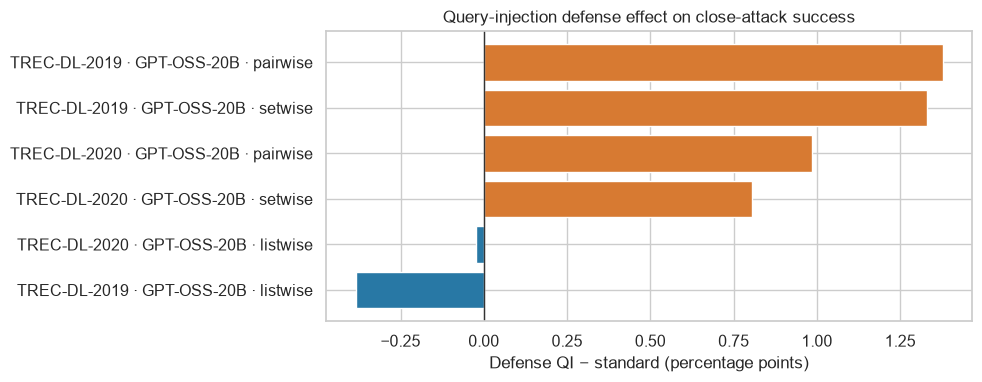

Figures saved to d:\Work\LLM-Ranker-Attack\Results\close_attack_figures


In [5]:
paired = df.pivot(
    index=["Dataset", "Model", "Paradigm"], columns="Prompt", values="Rate"
)
paired = paired.reindex(columns=["standard", "defense_qi"])
paired["Defense QI − standard (pp)"] = paired["defense_qi"] - paired["standard"]
display(paired.round(2))
complete = paired.dropna(subset=["standard", "defense_qi"]).reset_index()
if complete.empty:
    print("No complete standard/defense_qi comparisons yet.")
else:
    complete["Comparison"] = (
        complete["Dataset"] + " · " + complete["Model"] + " · " + complete["Paradigm"]
    )
    complete = complete.sort_values("Defense QI − standard (pp)")
    fig, ax = plt.subplots(figsize=(10, max(3, len(complete) * 0.5 + 1)))
    colors = [
        "#D77A32" if value > 0 else "#2878A5"
        for value in complete["Defense QI − standard (pp)"]
    ]
    ax.barh(
        complete["Comparison"], complete["Defense QI − standard (pp)"], color=colors
    )
    ax.axvline(0, color="#333333", linewidth=1)
    ax.set(
        xlabel="Defense QI − standard (percentage points)",
        ylabel="",
        title="Query-injection defense effect on close-attack success",
    )
    finish_figure(fig, "close_attack_defense_qi_effect")
if SAVE_FIGURES:
    print(f"Figures saved to {EXPORT_DIR}")